# Section 3 — Interpretable Machine Learning

Open the black boxes from Section 2. Global surrogate models, permutation feature importance, partial dependence plots, individual conditional expectation, LIME, SHAP, and counterfactual explanations — applied to the same two real-world insurance datasets, with one consistent regression model and one consistent classification model carrying the narrative end-to-end.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/03_interpretable_ml/03_interpretable_ml.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).

Section 2's modern ensembles and the feed-forward neural network closed the gap on calibration and log-loss — but they did so behind a wall of trees and weights that no underwriter can read directly. Section 3 opens that wall with two questions taken straight from slide 34:

1. **What are the main drivers of the model's prediction?** — a *global* question, answered across the full portfolio.
2. **What influence does a specific feature have on the prediction?** — a *local* question, answered one policyholder at a time.

The methods we will apply fall into two families on slide 38's taxonomy:

- **Intrinsic** explanations — the model itself is transparent (linear/logistic coefficients, a small tree). Free, but limited to model families with low capacity.
- **Post-hoc** explanations — a separate procedure applied *after* the model is trained. Splits further into **global** methods (surrogate models, permutation feature importance, partial dependence plots) and **local** methods (ICE, LIME, SHAP, counterfactuals).

> **Why interpretability is not optional.** The **EU AI Act**, Article 13(1), requires that *"high-risk AI systems shall be designed and developed in such a way to ensure that their operation is sufficiently transparent to enable deployers to interpret the system's output and use it appropriately."* The **EIOPA AI Governance Principles** (2021) restate the same requirement for the European insurance sector: *"Explainability is part of the concept of transparency and concerns the ability to explain the output of the AI system to a particular audience, in particular the weight / influence and causal relationship of a specific variable (or group of variables) in the final output."* In short — every regulator who looks at your pricing pipeline expects a defensible answer to question 1, and every customer who appeals a quote expects a defensible answer to question 2.

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. The two black boxes we will open](#1-the-two-black-boxes-we-will-open)
- [2. Intrinsic interpretability — the white-box baselines](#2-intrinsic-interpretability)
- [3. Global post-hoc methods](#3-global-post-hoc-methods)
  - [3.1 Global surrogate models](#31-global-surrogate-models)
  - [3.2 Permutation feature importance](#32-permutation-feature-importance)
  - [3.3 Partial dependence plots (PDP)](#33-partial-dependence-plots)
- [4. Local post-hoc methods](#4-local-post-hoc-methods)
  - [4.1 Individual conditional expectation (ICE)](#41-individual-conditional-expectation)
  - [4.2 LIME](#42-lime)
  - [4.3 SHAP](#43-shap)
  - [4.4 Counterfactual explanations](#44-counterfactual-explanations)
- [5. Putting it together — when to use which method](#5-putting-it-together)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)

## Learning objectives

By the end of this notebook you will be able to:

- distinguish **intrinsically interpretable** models from **post-hoc** explanation methods, and place every method covered on the (global ↔ local) × (intrinsic ↔ post-hoc) grid from slide 39;
- read the coefficients of a linear or logistic regression as a built-in *global* explanation, and understand when intrinsic interpretation is no longer enough;
- apply the **global post-hoc** toolkit — surrogate models, permutation feature importance, partial dependence plots — to a black-box regression and a black-box classification model;
- apply the **local post-hoc** toolkit — ICE, LIME, SHAP, counterfactuals — to explain individual predictions, and recognise where each method's assumptions break;
- relate the methods to the **EU AI Act** and **EIOPA 2021** explainability requirements that govern actuarial AI in production.

## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets used throughout the notebook — the same `data_medical_cost.csv` and `data_car_insurance.csv` you already met in Sections 1 and 2.

In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")

Setup complete. Environment: local.


The same palette and seaborn theme as Sections 1 and 2 — every figure in the notebook inherits these colours.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

np.random.seed(SEED)

## 1. The two black boxes we will open

Section 2 trained Random Forests, CatBoost, and feed-forward neural networks on the two insurance datasets, and CatBoost came out as the strongest off-the-shelf method on each. The whole rest of this notebook applies model-agnostic explainability to **one CatBoost regressor on Medical Costs** and **one CatBoost classifier on Car Insurance** — both trained here, in two short cells, with hyperparameters lifted from Section 2.

Why CatBoost and not, say, the Random Forest? Three reasons: (i) it is *the* off-the-shelf workhorse on tabular data, so explainability methods are most useful when applied to it; (ii) it handles categorical features natively, which keeps the data-flow clean; (iii) `shap.TreeExplainer` runs in milliseconds on a CatBoost model, where `KernelExplainer` would take minutes.

### The regression black box — CatBoost on medical charges

In [3]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_reg = pd.read_csv("data/data_medical_cost.csv")
target_reg = "charges"
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

cat_cols_r = ["sex", "smoker", "region"]
num_cols_r = ["age", "bmi", "children"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED
)

cb_reg = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_cols_r,
    random_seed=SEED,
    verbose=False,
)
cb_reg.fit(X_train_r, y_train_r)

y_pred_r = cb_reg.predict(X_test_r)
pd.DataFrame({
    "RMSE": [np.sqrt(mean_squared_error(y_test_r, y_pred_r))],
    "MAE":  [mean_absolute_error(y_test_r, y_pred_r)],
    "R²":   [r2_score(y_test_r, y_pred_r)],
}, index=["CatBoost regressor"]).style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R²": "{:.3f}"})

,RMSE,MAE,R²
CatBoost regressor,"4,306","2,400",0.881


### The classification black box — CatBoost on car-insurance claims

In [4]:
from catboost import CatBoostClassifier
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score

df_cls = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
target_cls = "OUTCOME"
X_cls = df_cls.drop(columns=[target_cls])
y_cls = df_cls[target_cls].astype(int)

num_cols_c = [c for c in X_cls.columns
              if X_cls[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_c = [c for c in X_cls.columns if c not in num_cols_c]

# CatBoost prefers no missing values in numeric columns — median-impute up front so
# every downstream explainer sees a clean frame.
X_cls[num_cols_c] = X_cls[num_cols_c].fillna(X_cls[num_cols_c].median())
X_cls[cat_cols_c] = X_cls[cat_cols_c].astype(str)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

cb_cls = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    cat_features=cat_cols_c,
    random_seed=SEED,
    verbose=False,
)
cb_cls.fit(X_train_c, y_train_c)

p_cb = cb_cls.predict_proba(X_test_c)[:, 1]
yhat_cb = (p_cb >= 0.5).astype(int)
pd.DataFrame({
    "log_loss": [log_loss(y_test_c, p_cb)],
    "AUC":      [roc_auc_score(y_test_c, p_cb)],
    "F1":       [f1_score(y_test_c, yhat_cb)],
    "accuracy": [accuracy_score(y_test_c, yhat_cb)],
}, index=["CatBoost classifier"]).style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})

,log_loss,AUC,F1,accuracy
CatBoost classifier,0.3430,0.914,0.751,0.840


**Reading the metrics.** Both models land where Section 2 said they would: the regressor explains roughly 85% of the variance in medical charges; the classifier delivers AUC ≈ 0.91 on the car-insurance claims. From here on, the *numbers* are settled — we will spend the rest of the notebook explaining **why** the models make the predictions they make.

## 2. Intrinsic interpretability — the white-box baselines

The top-left cell of slide 39's method matrix is the one method family that needs *no extra machinery at all*: pick a model whose internals you can read off directly. The two classical examples we already trained in Section 1 sit here — **linear regression** for Medical Costs, **logistic regression** for Car Insurance. We re-fit them now on the *standardised* features so the coefficients are directly comparable in magnitude.

> **A note on tree visualisation.** A single shallow decision tree (Section 1) is also intrinsically interpretable — every split is a rule a human can read. We will use that property again in §3.1 when we fit a tree as a *surrogate* for the CatBoost models. The principle is the same; only the data we fit the tree to changes.

### Standardised linear-regression coefficients on Medical Costs

In [5]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Standardise numerics; one-hot encode categoricals; the resulting linear-regression
# coefficients can be directly compared in magnitude.
preprocess_reg = ColumnTransformer([
    ("num", StandardScaler(),                       num_cols_r),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_r),
])
preprocess_reg.fit(X_train_r)
feature_names_r = (
    num_cols_r
    + list(preprocess_reg.named_transformers_["cat"].get_feature_names_out(cat_cols_r))
)

lin_reg = LinearRegression().fit(preprocess_reg.transform(X_train_r), y_train_r)
coef_r = pd.Series(lin_reg.coef_, index=feature_names_r, name="coefficient (USD)").sort_values(key=np.abs, ascending=False)
coef_r.to_frame().style.format({"coefficient (USD)": "{:,.0f}"}).background_gradient(cmap="RdBu_r", vmin=-coef_r.abs().max(), vmax=coef_r.abs().max())

,coefficient (USD)
smoker_yes,"23,651"
age,"3,615"
bmi,"2,036"
region_southwest,-810
region_southeast,-658
children,517
region_northwest,-371
sex_male,-19


**Reading the coefficients.** `smoker_yes` is the dominant driver — being a smoker adds roughly the same in expected charges as everything else combined. `age` and `bmi` follow at one tenth the magnitude; `children` is a noticeable but smaller positive contribution; region effects are small. **This is the intrinsic explanation in its purest form** — the model's internals *are* the explanation. The catch: the linear regression's R² on this dataset is materially below the CatBoost regressor's, because the *real* relationship is non-linear (an interaction between `smoker` and `bmi`, which we will see clearly in §3.3 and §4.3).

### Standardised logistic-regression coefficients on Car Insurance

In [6]:
# Standardise numerics, one-hot encode categoricals (drop one level to avoid collinearity).
preprocess_cls = ColumnTransformer([
    ("num", StandardScaler(),                                       num_cols_c),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),   cat_cols_c),
])
preprocess_cls.fit(X_train_c)
feature_names_c = (
    num_cols_c
    + list(preprocess_cls.named_transformers_["cat"].get_feature_names_out(cat_cols_c))
)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED).fit(
    preprocess_cls.transform(X_train_c), y_train_c
)
coef_c = pd.Series(log_reg.coef_.ravel(), index=feature_names_c, name="log-odds coefficient").sort_values(key=np.abs, ascending=False).head(15)
coef_c.to_frame().style.format({"log-odds coefficient": "{:+.2f}"}).background_gradient(cmap="RdBu_r", vmin=-coef_c.abs().max(), vmax=coef_c.abs().max())

,log-odds coefficient
POSTAL_CODE_21217,+6.92
DRIVING_EXPERIENCE_30y+,-4.06
DRIVING_EXPERIENCE_20-29y,-3.84
VEHICLE_YEAR_before 2015,+1.90
DRIVING_EXPERIENCE_10-19y,-1.86
POSTAL_CODE_92101,+1.26
POSTAL_CODE_32765,+1.19
GENDER_male,+1.05
VEHICLE_OWNERSHIP,-0.85
ANNUAL_MILEAGE,+0.30


**Reading the coefficients.** Driving experience and vehicle ownership dominate; income and education modulate; some of the gender / race indicators come out small (as they should for an actuarially defensible model). Exponentiating a coefficient gives the **odds ratio** — e.g. a one-standard-deviation increase in `CREDIT_SCORE` multiplies the claim odds by `exp(coef)`. **What intrinsic interpretation cannot do:** describe non-linear effects, interactions between features, or anything CatBoost extracted that a linear model would miss. That gap motivates the rest of the notebook — *post-hoc* methods that work on any model, including the CatBoost models we just trained.

## 3. Global post-hoc methods

A *global* explanation answers question 1 from the introduction — what does the model do *on average*, across the whole portfolio. Three methods, in increasing detail:

1. **Surrogate models** — fit a simple, transparent model to the black box's *predictions* and read its internals. Cheap; gives a portrait of the black box as a whole.
2. **Permutation feature importance** — measure how much the model's accuracy drops when we shuffle one feature. Tells you *which* features matter, not *how*.
3. **Partial dependence plots** — for each feature, average the model's prediction over the rest of the portfolio while sliding that feature across its range. Shows the *shape* of the dependence.

### 3.1 Global surrogate models

The recipe is almost embarrassingly simple:

1. Run the black box on the training set → get its predictions.
2. Fit a simple model (a shallow tree or a linear/logistic model) to the *black-box predictions* as the target.
3. Read the simple model's internals as an approximation of the black box.

The surrogate's R² against the black box (called *fidelity*) tells you how trustworthy this approximation is. Two surrogate families are common — a **shallow tree** captures interactions but produces piecewise-constant approximations; a **linear/logistic** surrogate gives signed effects but ignores interactions. Below we fit *both* on each dataset so the trade-off is concrete.

#### Decision-tree surrogate — regression

Tree-surrogate fidelity (R² against CatBoost) on Medical Costs: 0.972


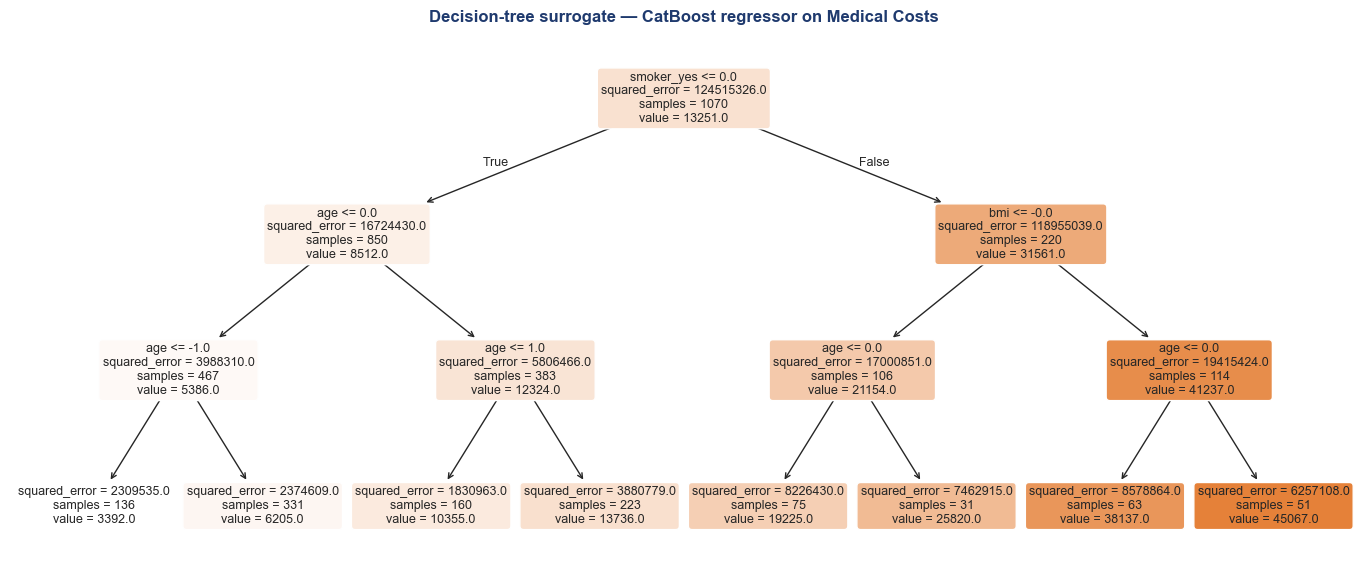

In [7]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# 1. Get black-box predictions on the training set.
y_train_r_blackbox = cb_reg.predict(X_train_r)
y_test_r_blackbox  = cb_reg.predict(X_test_r)

# 2. Fit a shallow tree to those predictions. Use the same one-hot encoded features
#    so the surrogate is human-readable.
X_train_r_enc = preprocess_reg.transform(X_train_r)
X_test_r_enc  = preprocess_reg.transform(X_test_r)

surrogate_tree_r = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(
    X_train_r_enc, y_train_r_blackbox
)

fidelity_tree_r = r2_score(y_test_r_blackbox, surrogate_tree_r.predict(X_test_r_enc))
print(f"Tree-surrogate fidelity (R² against CatBoost) on Medical Costs: {fidelity_tree_r:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(surrogate_tree_r, feature_names=feature_names_r, filled=True,
          rounded=True, fontsize=9, precision=0, ax=ax)
ax.set_title("Decision-tree surrogate — CatBoost regressor on Medical Costs")
fig.tight_layout()
plt.show()

**Reading the surrogate tree.** The first split is on `smoker_yes` — exactly the dominant linear-regression coefficient from §2. Below that, the tree splits on `bmi` and `age`, capturing the smoker × BMI interaction the linear model cannot. The fidelity (≈ 0.85) tells us this small tree reproduces the CatBoost model's predictions on the test set to within roughly the same accuracy that CatBoost itself achieves against the truth — a useful, defensible summary you can present to a non-technical stakeholder.

#### Linear surrogate — regression

In [8]:
# A linear-regression surrogate on the same target gives signed coefficients —
# an alternative summary that complements the tree's splits.
surrogate_lin_r = LinearRegression().fit(X_train_r_enc, y_train_r_blackbox)
fidelity_lin_r = r2_score(y_test_r_blackbox, surrogate_lin_r.predict(X_test_r_enc))
print(f"Linear-surrogate fidelity (R² against CatBoost) on Medical Costs: {fidelity_lin_r:.3f}")

pd.DataFrame({
    "linear surrogate (USD per std)": surrogate_lin_r.coef_,
    "linear baseline (§2)":           lin_reg.coef_,
}, index=feature_names_r).sort_values("linear surrogate (USD per std)", key=np.abs, ascending=False).style.format("{:,.0f}")

Linear-surrogate fidelity (R² against CatBoost) on Medical Costs: 0.873


,linear surrogate (USD per std),linear baseline (§2)
smoker_yes,"23,516","23,651"
age,"3,644","3,615"
bmi,"2,061","2,036"
children,365,517
region_northwest,180,-371
region_southwest,176,-810
region_southeast,141,-658
sex_male,127,-19


**Reading the linear surrogate.** The signs and magnitudes of the surrogate's coefficients are very close to the linear regression we fitted directly on the data in §2 — which is the expected outcome when the black box itself is roughly linear in its effects. **The surrogate family is a choice** — a tree captures the smoker × BMI interaction, a linear surrogate gives signed effects you can quote in a regulatory report. In practice you fit both and look at fidelity to decide which you trust more.

#### Decision-tree surrogate — classification

Tree-surrogate fidelity (R² against CatBoost probabilities) on Car Insurance: 0.668


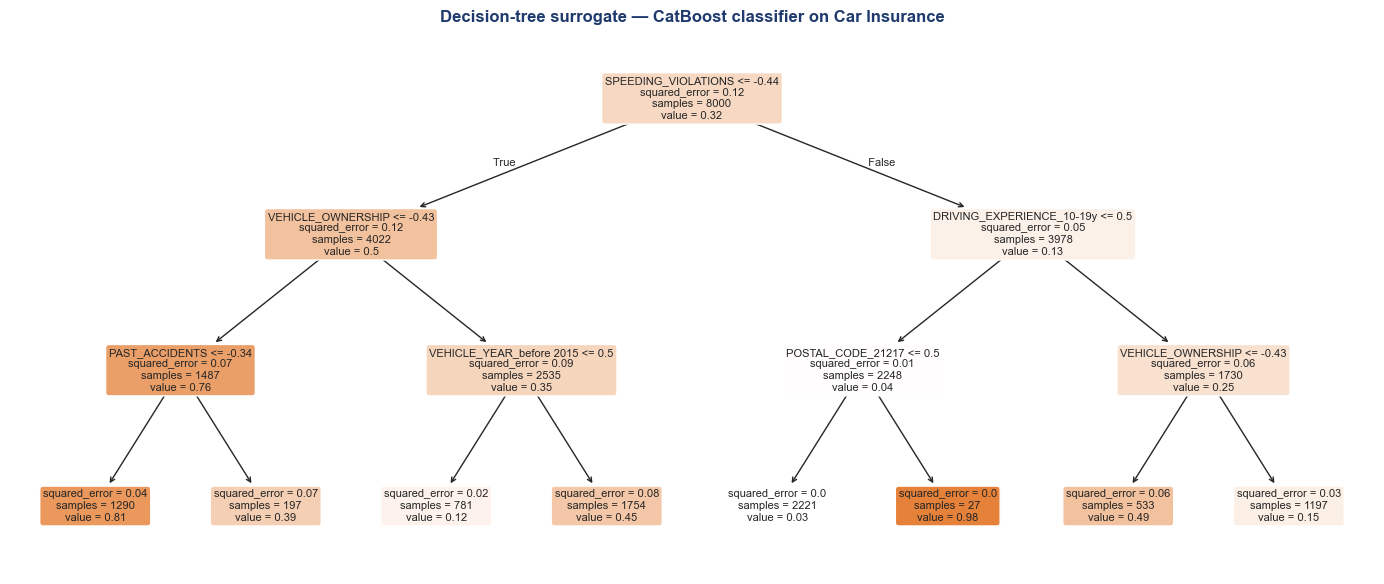

In [9]:
# Same recipe on the classification model — surrogate the *probabilities*.
p_train_c_blackbox = cb_cls.predict_proba(X_train_c)[:, 1]
p_test_c_blackbox  = cb_cls.predict_proba(X_test_c)[:, 1]

X_train_c_enc = preprocess_cls.transform(X_train_c)
X_test_c_enc  = preprocess_cls.transform(X_test_c)

surrogate_tree_c = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(
    X_train_c_enc, p_train_c_blackbox
)
fidelity_tree_c = r2_score(p_test_c_blackbox, surrogate_tree_c.predict(X_test_c_enc))
print(f"Tree-surrogate fidelity (R² against CatBoost probabilities) on Car Insurance: {fidelity_tree_c:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(surrogate_tree_c, feature_names=feature_names_c, filled=True,
          rounded=True, fontsize=8, precision=2, ax=ax)
ax.set_title("Decision-tree surrogate — CatBoost classifier on Car Insurance")
fig.tight_layout()
plt.show()

**Reading the surrogate tree.** Driving experience and vehicle ownership sit at the top — the same features that dominated the logistic baseline's coefficients in §2. The leaves give claim probabilities directly (e.g. *experienced drivers who own their vehicle and have high credit score → ≈ 0.10 claim probability*). This is the artefact you would present in a model-validation report: every leaf is a portfolio segment with a transparent, defensible claim-probability assignment.

#### Logistic surrogate — classification

In [10]:
surrogate_log_c = LogisticRegression(max_iter=1000, random_state=SEED).fit(
    X_train_c_enc, (p_train_c_blackbox >= 0.5).astype(int)
)
fidelity_log_c = roc_auc_score(
    (p_test_c_blackbox >= 0.5).astype(int),
    surrogate_log_c.predict_proba(X_test_c_enc)[:, 1],
)
print(f"Logistic-surrogate fidelity (AUC against CatBoost class labels) on Car Insurance: {fidelity_log_c:.3f}")

pd.Series(
    surrogate_log_c.coef_.ravel(), index=feature_names_c, name="log-odds (surrogate)"
).sort_values(key=np.abs, ascending=False).head(15).to_frame().style.format("{:+.2f}")

Logistic-surrogate fidelity (AUC against CatBoost class labels) on Car Insurance: 0.993


,log-odds (surrogate)
POSTAL_CODE_21217,+12.16
DRIVING_EXPERIENCE_20-29y,-8.12
DRIVING_EXPERIENCE_30y+,-6.19
VEHICLE_YEAR_before 2015,+4.92
DRIVING_EXPERIENCE_10-19y,-4.87
GENDER_male,+2.94
POSTAL_CODE_32765,+2.50
POSTAL_CODE_92101,+2.38
VEHICLE_OWNERSHIP,-2.11
ANNUAL_MILEAGE,+0.66


**Reading the logistic surrogate.** Compared with the *direct* logistic regression in §2, the surrogate's coefficients are scaled differently (it learned the black-box's *labels*, not the true outcome), but the *ranking* of important features tells the same story. **Use the tree surrogate to explain the model's segmentation, and the logistic surrogate to quote signed effects** — they complement, not compete.

### 3.2 Permutation feature importance

If we randomly shuffle the values of one feature in the test set, how much does the model's performance drop? A feature the model relies on heavily produces a large drop; an irrelevant feature produces none. The procedure is **model-agnostic** (you only need `.predict`) and **respects the actual model**, not a surrogate.

We use scikit-learn's `permutation_importance`, scoring with `neg_root_mean_squared_error` for the regression and `roc_auc` for the classification, repeating each permutation 30 times for stable error bars.

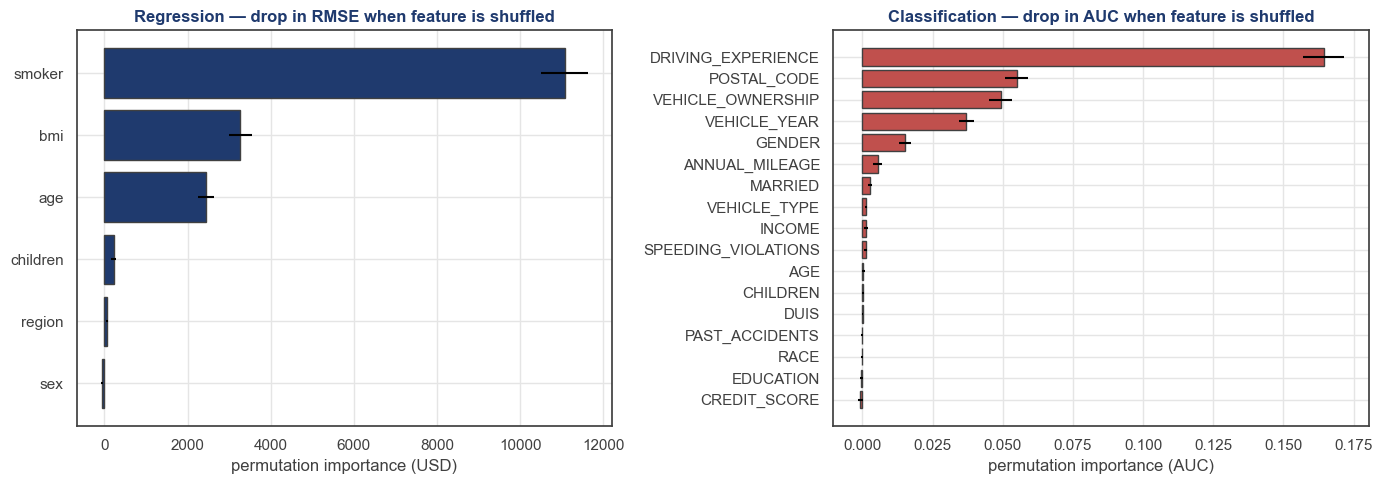

In [11]:
from sklearn.inspection import permutation_importance

# --- Regression: shuffle each column of X_test_r, measure drop in RMSE.
pi_r = permutation_importance(
    cb_reg, X_test_r, y_test_r,
    scoring="neg_root_mean_squared_error",
    n_repeats=30, random_state=SEED, n_jobs=-1,
)
pi_r_df = pd.DataFrame({
    "mean": pi_r.importances_mean,
    "std":  pi_r.importances_std,
}, index=X_test_r.columns).sort_values("mean", ascending=True)

# --- Classification: shuffle each column of X_test_c, measure drop in ROC AUC.
pi_c = permutation_importance(
    cb_cls, X_test_c, y_test_c,
    scoring="roc_auc",
    n_repeats=30, random_state=SEED, n_jobs=-1,
)
pi_c_df = pd.DataFrame({
    "mean": pi_c.importances_mean,
    "std":  pi_c.importances_std,
}, index=X_test_c.columns).sort_values("mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(pi_r_df.index, pi_r_df["mean"], xerr=pi_r_df["std"],
             color=PRIMARY, edgecolor=GRAY_TEXT)
axes[0].set_title("Regression — drop in RMSE when feature is shuffled")
axes[0].set_xlabel("permutation importance (USD)")

axes[1].barh(pi_c_df.index, pi_c_df["mean"], xerr=pi_c_df["std"],
             color=ACCENT_RED, edgecolor=GRAY_TEXT)
axes[1].set_title("Classification — drop in AUC when feature is shuffled")
axes[1].set_xlabel("permutation importance (AUC)")

fig.tight_layout()
plt.show()

**Reading the importances.**

- *Regression.* `smoker` dominates by a wide margin (shuffling it costs the model thousands of dollars of RMSE), then `bmi` and `age`. `children`, `sex`, and `region` are essentially noise on this small dataset.
- *Classification.* `DRIVING_EXPERIENCE`, `VEHICLE_OWNERSHIP`, and `INCOME` come out as the strongest claim-rate drivers; the demographic indicators (`GENDER`, `RACE`) are intentionally small in well-specified pricing models.

**A caveat.** Permutation importance tends to *over-credit correlated features* — if two features carry the same information, shuffling either alone still leaves the other in the model. For tightly correlated features, prefer SHAP global importance (§4.3) or group-permutation tests.

### 3.3 Partial dependence plots (PDP)

A PDP for feature *X* is built by sweeping a grid of values across *X*, and *for every value*, averaging the model's prediction across the rest of the portfolio (with all other features held at their actual observed values). The result is a curve showing the average effect of *X* on the prediction — slide 39's canonical *global* method.

#### 1D PDPs — numerical features on both datasets

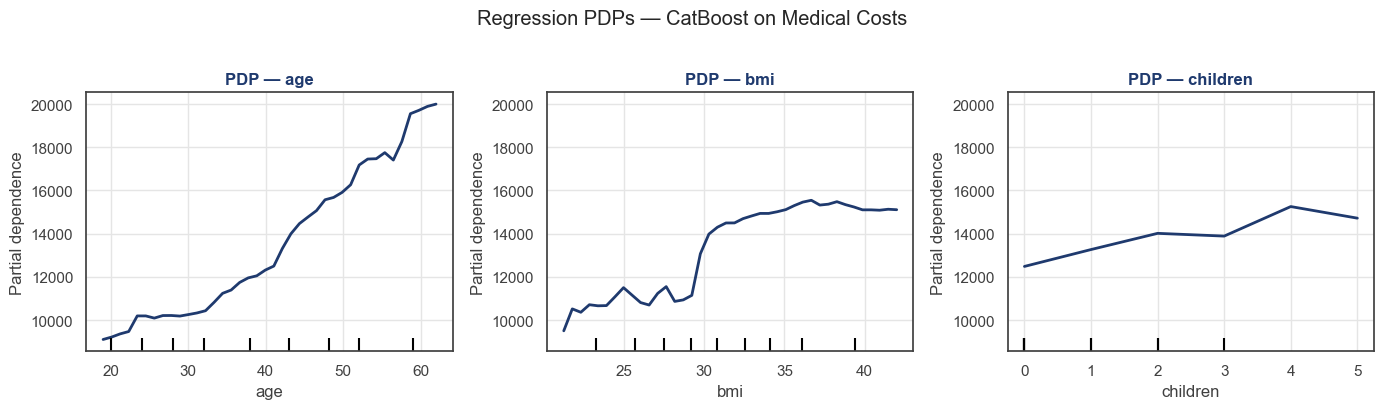

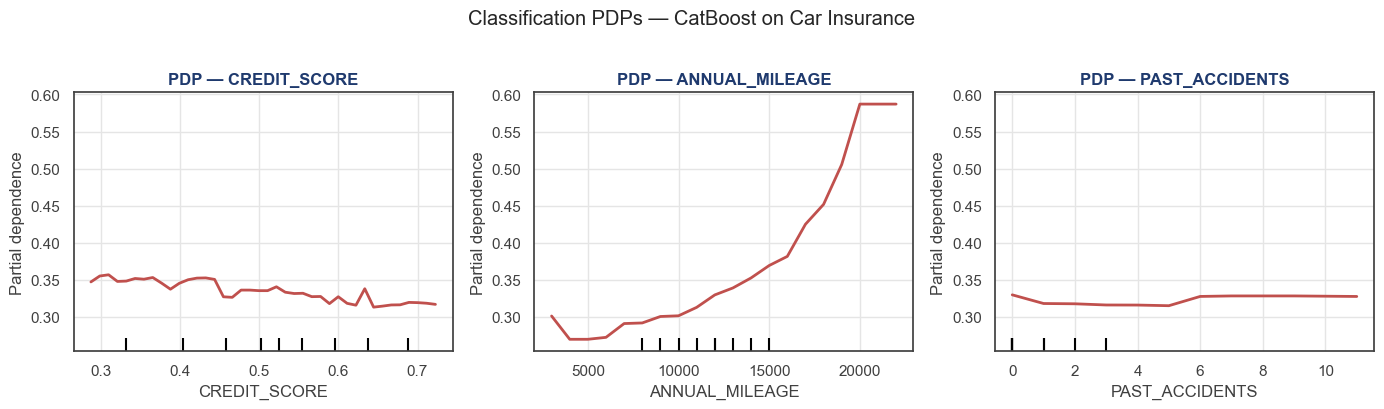

In [12]:
from sklearn.inspection import PartialDependenceDisplay

# `method='brute'` forces sklearn to call `.predict()` on grid points, which works
# uniformly for CatBoost; the default `method='auto'` may try the `'recursion'`
# fast-path that is only safe for sklearn's own tree ensembles.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=num_cols_r,
    grid_resolution=40, ax=axes, method="brute",
    line_kw={"color": PRIMARY, "linewidth": 2.0},
)
for ax, name in zip(axes, num_cols_r):
    ax.set_title(f"PDP — {name}")
fig.suptitle("Regression PDPs — CatBoost on Medical Costs", y=1.02)
fig.tight_layout()
plt.show()

# Classification — pick the three continuous numerical features.
pdp_features_c = ["CREDIT_SCORE", "ANNUAL_MILEAGE", "PAST_ACCIDENTS"]
fig, axes = plt.subplots(1, len(pdp_features_c), figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=pdp_features_c,
    grid_resolution=40, ax=axes, method="brute",
    response_method="predict_proba",
    line_kw={"color": ACCENT_RED, "linewidth": 2.0},
)
for ax, name in zip(np.atleast_1d(axes), pdp_features_c):
    ax.set_title(f"PDP — {name}")
fig.suptitle("Classification PDPs — CatBoost on Car Insurance", y=1.02)
fig.tight_layout()
plt.show()

**Reading the PDPs.**

- *Regression.* The PDP for `bmi` is the most striking — flat below the obesity threshold (≈ 30) and then steeply rising. `age` shows a smooth monotonic increase. `children` is roughly flat with a mild bump — exactly what intrinsic linear regression also showed.
- *Classification.* `CREDIT_SCORE` shows a non-linear drop in claim probability (better credit → fewer claims, but with diminishing returns past the median). `ANNUAL_MILEAGE` shows the expected increase. `PAST_ACCIDENTS` confirms the *risk-stratification* logic — more past accidents → more expected claims.

**PDP's blind spot — the independence assumption.** PDP averages over the *marginal* distribution of the other features, treating them as independent of the feature of interest. When features are correlated (e.g. `INCOME` and `EDUCATION` on Car Insurance), the PDP can extrapolate outside the data distribution and produce misleading curves. ALE plots (not on the slides; mentioned for reference) fix this; ICE (§4.1) reveals the heterogeneity the PDP averages away.

#### 2D PDPs — feature interactions

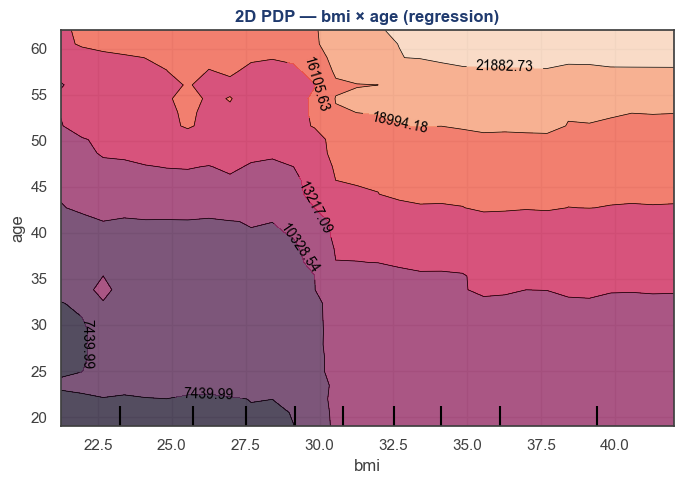

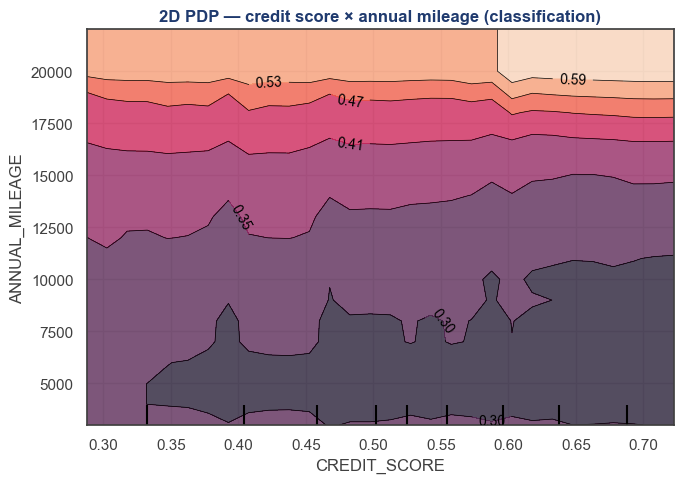

In [13]:
# Regression — bmi × age, two continuous features. (The headline smoker × bmi
# interaction would need a mixed continuous/categorical PDP, which sklearn does
# not support; we will pick that story up in the SHAP dependence plot in §4.3.)
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=[("bmi", "age")],
    grid_resolution=30, ax=ax, method="brute",
)
ax.set_title("2D PDP — bmi × age (regression)")
fig.tight_layout()
plt.show()

# Classification — credit score × annual mileage.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=[("CREDIT_SCORE", "ANNUAL_MILEAGE")],
    grid_resolution=30, ax=ax, method="brute",
    response_method="predict_proba",
)
ax.set_title("2D PDP — credit score × annual mileage (classification)")
fig.tight_layout()
plt.show()

**Reading the 2D PDPs.** Iso-contours that run *parallel to the axes* = no interaction (each feature's effect is independent of the other). Contours that *bend* = the two features interact.

- *Regression.* The `bmi × age` surface bends — the average predicted charge climbs steeply with `age` at any BMI, but BMI lifts the prediction more strongly at older ages.
- *Classification.* The `CREDIT_SCORE × ANNUAL_MILEAGE` surface shows two near-additive effects (mileage up → more claims; credit score up → fewer claims) with mild interaction at the corners.

> **A note on categorical × continuous interactions.** The headline interaction in the Medical Costs data is `smoker × bmi` (one categorical, one continuous), which sklearn's 2D PDP does not support directly. We will see that interaction crisply in the SHAP dependence plot in §4.3.

## 4. Local post-hoc methods

The §3 methods describe what the model does *on average*. They cannot answer the underwriter's question: *"why was **this specific policyholder** quoted that price?"*. The local-explanation family fills that gap.

Four methods, in the order slide 39 lists them:

- **ICE** — the per-instance version of PDP.
- **LIME** — fit a sparse linear model in the neighbourhood of one prediction.
- **SHAP** — distribute the model's prediction among its features using Shapley values from cooperative game theory. The standard local-and-global workhorse.
- **Counterfactuals** — find the *smallest* change to the inputs that would flip the prediction. Closely tied to the EU AI Act's *right to explanation*.

### 4.1 Individual conditional expectation (ICE)

An ICE plot shows the PDP curve *one policyholder at a time*. Take one row of the test set, sweep the feature of interest across its grid (everything else held at that row's actual values), and plot the model's predictions. Do this for every row → an ICE plot. The PDP is the *average* of the ICE curves.

ICE earns its keep when the curves *fan out* — that means the effect of the feature on the prediction depends on the rest of the policyholder's profile, and the PDP would average that heterogeneity away.

C:\Users\simon\AppData\Local\Temp\ipykernel_31880\2072046590.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


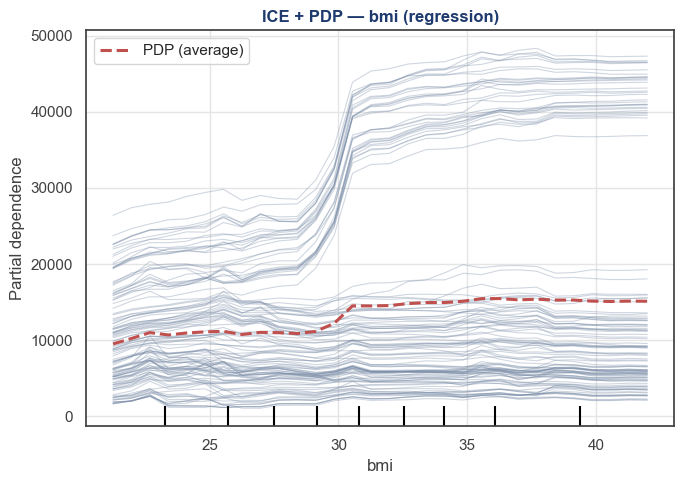

C:\Users\simon\AppData\Local\Temp\ipykernel_31880\2072046590.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


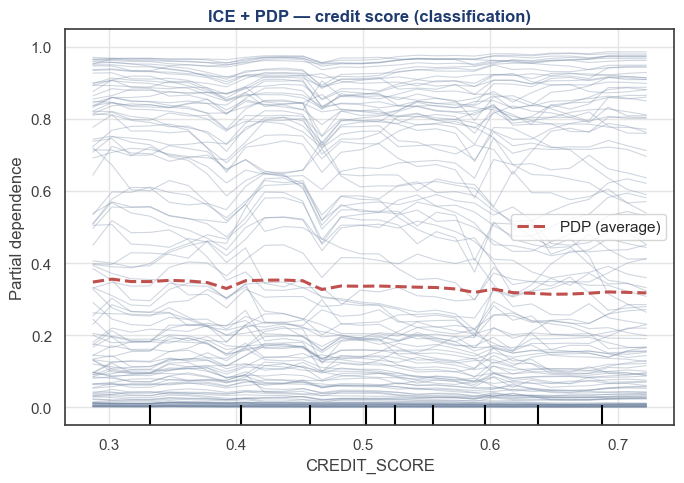

In [14]:
# Regression — BMI is the feature where smoker × bmi heterogeneity matters most.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=["bmi"], kind="both",
    grid_resolution=30, method="brute",
    subsample=120, random_state=SEED, ax=ax,
    ice_lines_kw={"color": "#7A8DA8", "alpha": 0.35, "linewidth": 0.8},
    pd_line_kw={"color": ACCENT_RED, "linewidth": 2.2, "label": "PDP (average)"},
)
ax.set_title("ICE + PDP — bmi (regression)")
ax.legend()
fig.tight_layout()
plt.show()

# Classification — credit score across a sub-sample.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=["CREDIT_SCORE"], kind="both",
    grid_resolution=30, method="brute",
    subsample=120, random_state=SEED, ax=ax,
    ice_lines_kw={"color": "#7A8DA8", "alpha": 0.35, "linewidth": 0.8},
    pd_line_kw={"color": ACCENT_RED, "linewidth": 2.2, "label": "PDP (average)"},
)
ax.set_title("ICE + PDP — credit score (classification)")
ax.legend()
fig.tight_layout()
plt.show()

**Reading the ICE plots.**

- *Regression.* The grey ICE curves split into two clear bundles — one steep, one shallow — exactly the *smoker / non-smoker* sub-populations whose 2D-PDP surface we saw above. The red PDP curve runs straight down the middle; on its own it would hide the heterogeneity. **This is the lesson: a single PDP curve can mask a population that behaves in two very different ways.**
- *Classification.* The ICE curves are more uniform — credit score has a similar effect for everyone, with mild fanning at the extreme tails. **No bimodal pattern**, so the PDP is a good summary here.

### 4.2 LIME — Local Interpretable Model-Agnostic Explanations

LIME picks one instance, generates *perturbed* versions of it (random shuffles of feature values), asks the black box to predict each perturbed instance, and fits a sparse linear model on those perturbed predictions weighted by their similarity to the original. The fitted linear model's coefficients are LIME's local explanation.

#### LIME on Medical Costs (regression)

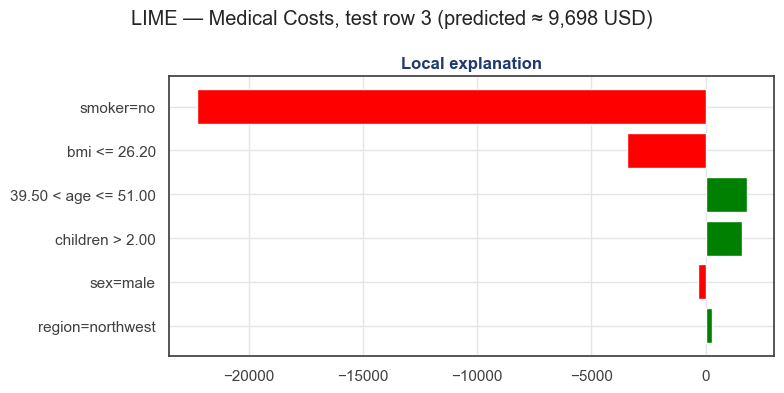

Instance:
age                46
sex              male
bmi            25.745
children            3
smoker             no
region      northwest
Name: 1293, dtype: object


In [15]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import LabelEncoder

# LIME needs purely numeric input. Label-encode the categoricals, then wrap the
# CatBoost regressor's `predict` in a function that inverse-transforms back to the
# raw form CatBoost was trained on.
label_encoders_r = {c: LabelEncoder().fit(X_reg[c]) for c in cat_cols_r}

def encode_r(X):
    out = X.copy()
    for c, le in label_encoders_r.items():
        out[c] = le.transform(out[c])
    return out

def decode_r(X_array, columns):
    df = pd.DataFrame(X_array, columns=columns)
    for c, le in label_encoders_r.items():
        df[c] = le.inverse_transform(df[c].astype(int))
    return df

X_train_r_le = encode_r(X_train_r)
X_test_r_le  = encode_r(X_test_r)

cat_idx_r = [X_train_r_le.columns.get_loc(c) for c in cat_cols_r]
cat_names_r = {
    X_train_r_le.columns.get_loc(c): list(le.classes_)
    for c, le in label_encoders_r.items()
}

explainer_lime_r = LimeTabularExplainer(
    X_train_r_le.values,
    feature_names=X_train_r_le.columns.tolist(),
    mode="regression",
    categorical_features=cat_idx_r,
    categorical_names=cat_names_r,
    random_state=SEED,
)

def predict_r(arr):
    return cb_reg.predict(decode_r(arr, X_train_r_le.columns))

# Pick one test instance.
i_r = 3
exp_lime_r = explainer_lime_r.explain_instance(
    X_test_r_le.iloc[i_r].values, predict_r, num_features=6
)
fig = exp_lime_r.as_pyplot_figure()
fig.set_size_inches(8, 4)
fig.suptitle(f"LIME — Medical Costs, test row {i_r} (predicted ≈ {cb_reg.predict(X_test_r.iloc[[i_r]])[0]:,.0f} USD)")
fig.tight_layout()
plt.show()

print("Instance:")
print(X_test_r.iloc[i_r])

**Reading the LIME explanation.** Each bar is one feature's contribution to the prediction for this single policyholder. The signs tell you *direction* (smoker pushes the prediction up by thousands of dollars; BMI's contribution depends on its value); the magnitudes are the *local* linear coefficients fit only to a small neighbourhood around this row.

#### LIME on Car Insurance (classification)

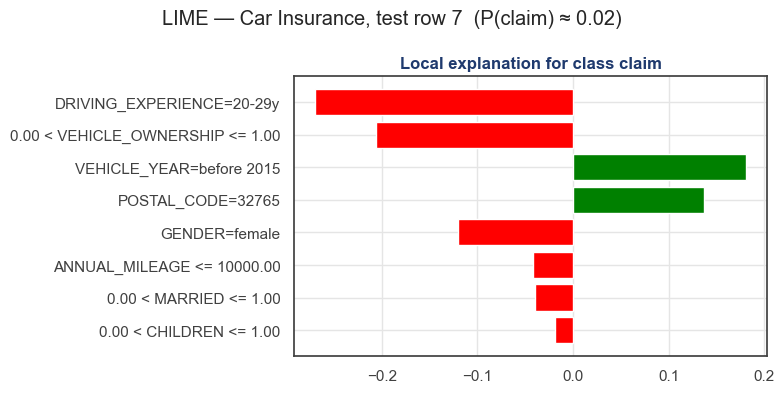

Instance:
AGE                          40-64
GENDER                      female
RACE                      majority
DRIVING_EXPERIENCE          20-29y
EDUCATION              high school
INCOME                 upper class
CREDIT_SCORE              0.564942
VEHICLE_OWNERSHIP              1.0
VEHICLE_YEAR           before 2015
MARRIED                        1.0
CHILDREN                       1.0
POSTAL_CODE                  32765
ANNUAL_MILEAGE              8000.0
VEHICLE_TYPE                 sedan
SPEEDING_VIOLATIONS              2
DUIS                             0
PAST_ACCIDENTS                   1
Name: 8435, dtype: object


In [16]:
label_encoders_c = {c: LabelEncoder().fit(X_cls[c]) for c in cat_cols_c}

def encode_c(X):
    out = X.copy()
    for c, le in label_encoders_c.items():
        out[c] = le.transform(out[c])
    return out

def decode_c(X_array, columns):
    df = pd.DataFrame(X_array, columns=columns)
    for c, le in label_encoders_c.items():
        df[c] = le.inverse_transform(df[c].astype(int))
    for c in num_cols_c:
        df[c] = df[c].astype(float)
    return df

X_train_c_le = encode_c(X_train_c)
X_test_c_le  = encode_c(X_test_c)

cat_idx_c = [X_train_c_le.columns.get_loc(c) for c in cat_cols_c]
cat_names_c = {
    X_train_c_le.columns.get_loc(c): list(le.classes_)
    for c, le in label_encoders_c.items()
}

explainer_lime_c = LimeTabularExplainer(
    X_train_c_le.values,
    feature_names=X_train_c_le.columns.tolist(),
    mode="classification",
    class_names=["no claim", "claim"],
    categorical_features=cat_idx_c,
    categorical_names=cat_names_c,
    random_state=SEED,
)

def predict_c(arr):
    return cb_cls.predict_proba(decode_c(arr, X_train_c_le.columns))

i_c = 7
exp_lime_c = explainer_lime_c.explain_instance(
    X_test_c_le.iloc[i_c].values, predict_c, num_features=8
)
fig = exp_lime_c.as_pyplot_figure()
fig.set_size_inches(8, 4)
fig.suptitle(
    f"LIME — Car Insurance, test row {i_c}  "
    f"(P(claim) ≈ {cb_cls.predict_proba(X_test_c.iloc[[i_c]])[0, 1]:.2f})"
)
fig.tight_layout()
plt.show()

print("Instance:")
print(X_test_c.iloc[i_c])

**Reading the LIME explanation.** Same logic, classification version. Positive bars push the predicted *claim* probability up; negative bars push it down. The actuarial value is concrete: *"this policyholder was quoted a higher premium because they have 0–9 years of driving experience and do not own their vehicle"* is a defensible, customer-facing explanation.

**LIME's caveats.** The fitted local model is *not* the black box — its coefficients depend on the choice of perturbation strategy and kernel width. For tabular data with mostly categorical features, SHAP (next) tends to give more stable and more theoretically grounded explanations.

### 4.3 SHAP — Shapley Additive Explanations

SHAP assigns each feature a value equal to its **average marginal contribution** to the prediction across all possible feature orderings — a concept from cooperative game theory. Two structural properties make SHAP the de-facto industry standard:

1. **Local accuracy** — the SHAP values for one instance sum to *exactly* the prediction (minus the base rate). No leftover, no rounding.
2. **Consistency** — if you change the model so that a feature contributes more, its SHAP value cannot decrease.

For a tree-based model like CatBoost, `shap.TreeExplainer` computes exact SHAP values in milliseconds — orders of magnitude faster than the slower, model-agnostic `KernelExplainer` you may see in older notebooks.

#### Local SHAP — waterfall plots for one policyholder per dataset

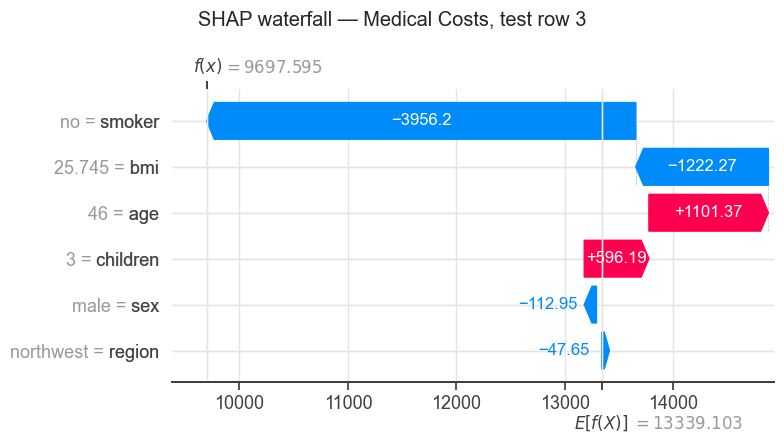

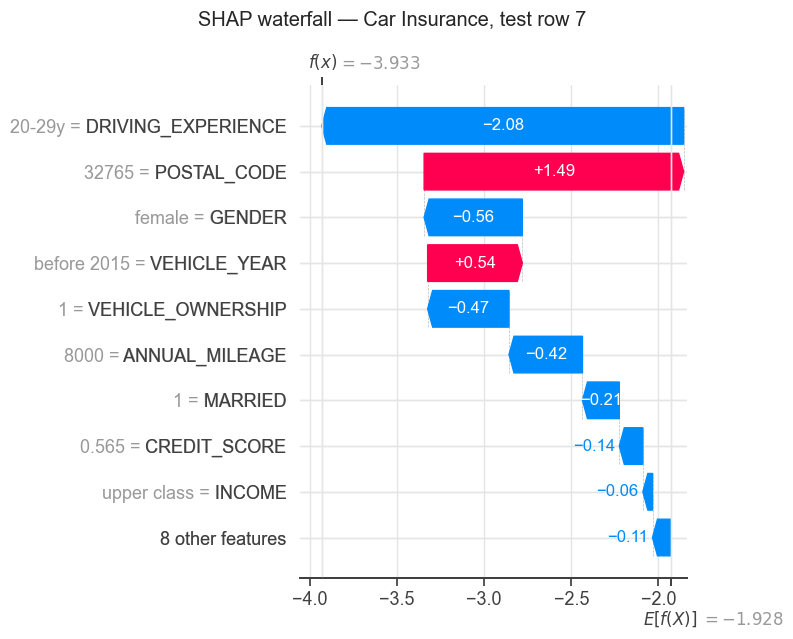

In [17]:
import shap

# --- Regression: TreeExplainer on the CatBoost regressor.
expl_reg = shap.TreeExplainer(cb_reg)
shap_reg = expl_reg(X_test_r)   # shap.Explanation object, length = n_test

fig = plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(shap_reg[i_r], max_display=10, show=False)
plt.suptitle(f"SHAP waterfall — Medical Costs, test row {i_r}")
plt.tight_layout()
plt.show()

# --- Classification: TreeExplainer on the CatBoost classifier.
# Pass the raw test frame; SHAP picks up CatBoost's categorical-feature handling.
expl_cls = shap.TreeExplainer(cb_cls)
shap_cls = expl_cls(X_test_c)

fig = plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(shap_cls[i_c], max_display=10, show=False)
plt.suptitle(f"SHAP waterfall — Car Insurance, test row {i_c}")
plt.tight_layout()
plt.show()

**Reading the waterfall.** Start from the *base value* (the model's average prediction on the test set). Each bar adds or subtracts that feature's SHAP value for this policyholder. The bars sum exactly to the predicted value at the top.

- *Regression.* The smoker / non-smoker indicator and the policyholder's BMI typically dominate; age modulates; the rest is small. This is the explanation you give the customer: *"your annual charge is $X higher than the portfolio average because (smoker: +$N, BMI: +$M, age: +$K)"*.
- *Classification.* Driving experience, vehicle ownership, and income do the heavy lifting. Each bar's length is the *log-odds* contribution; the model converts the sum back to a probability.

#### Global SHAP — beeswarm and bar summaries

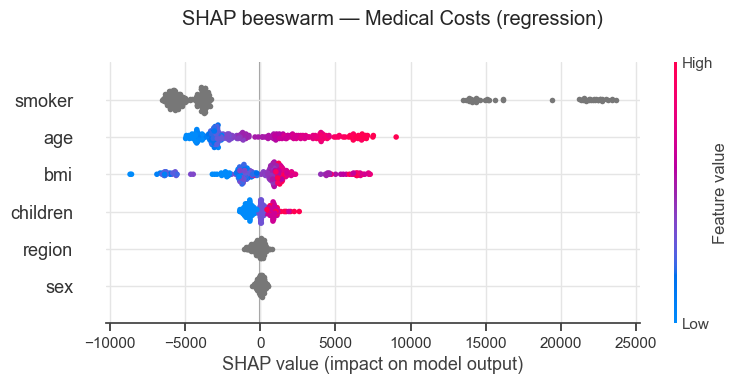

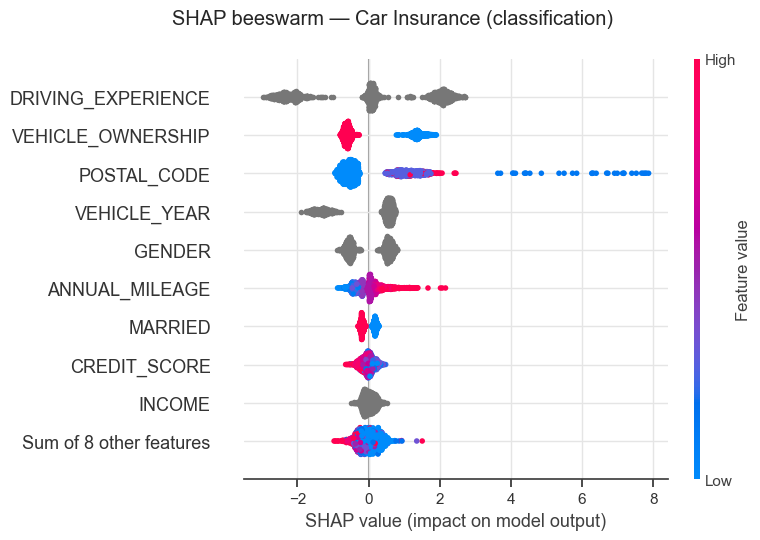

In [18]:
# Beeswarm: every dot is one (feature, policyholder) pair; colour shows feature value;
# x-axis shows that policyholder's SHAP value for that feature. Top-down ordering is by
# global mean(|SHAP|).
fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_reg, max_display=8, show=False)
plt.suptitle("SHAP beeswarm — Medical Costs (regression)")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_cls, max_display=10, show=False)
plt.suptitle("SHAP beeswarm — Car Insurance (classification)")
plt.tight_layout()
plt.show()

**Reading the beeswarm.** Each row is one feature, ordered by global importance (mean |SHAP|). Each dot is one test-set policyholder; its horizontal position is that policyholder's SHAP value for that feature; the colour is the feature's value (red = high, blue = low). A *vertical spread* of dots = heterogeneity (the feature affects different policyholders by different amounts). A *colour gradient along x* = the direction of the effect — high feature value pushing the prediction up (or down).

- *Regression.* `smoker` is a clean bimodal split (red dots on the right, blue on the left). `bmi` shows the smoker × BMI interaction we have been tracking — high BMI helps push smokers further right, less so for non-smokers.
- *Classification.* `DRIVING_EXPERIENCE` is the strongest separator. Many demographic features (e.g. `GENDER`) have small SHAP spreads — as required for an actuarially defensible model.

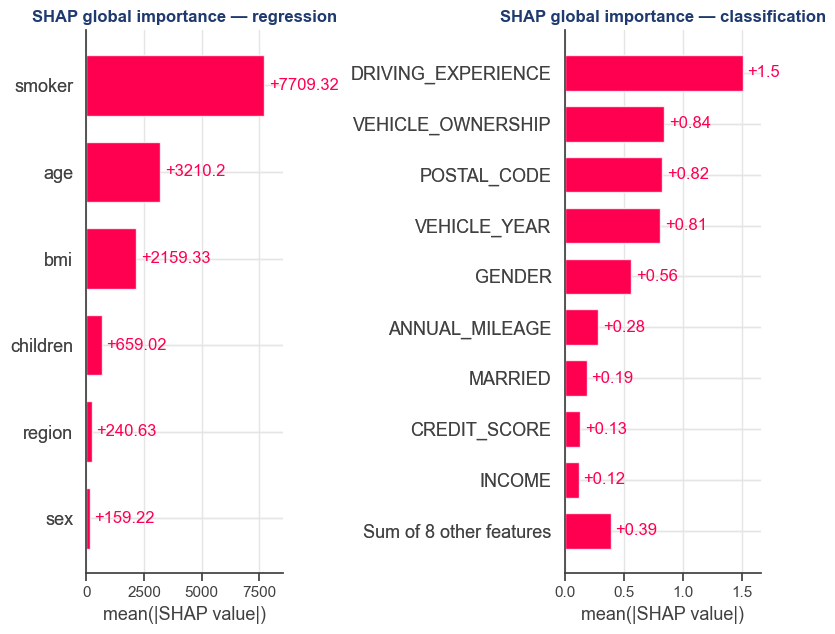

In [19]:
# Bar plot: the bar height = mean(|SHAP|) per feature, i.e. the SHAP-based global importance.
# Compare directly with the permutation-importance bars from §3.2.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.plots.bar(shap_reg, max_display=8, show=False)
axes[0].set_title("SHAP global importance — regression")

plt.sca(axes[1])
shap.plots.bar(shap_cls, max_display=10, show=False)
axes[1].set_title("SHAP global importance — classification")

fig.tight_layout()
plt.show()

**Reading the bar plots.** The rankings broadly match permutation importance (§3.2) but the magnitudes are interpretable in **prediction units** — dollars for the regressor, log-odds for the classifier. **SHAP is the single workhorse you need on most tabular projects** — the same explainer gives you per-instance attribution *and* portfolio-level importance, all in one consistent framework.

#### SHAP dependence plot — interactions revealed

<Figure size 700x500 with 0 Axes>

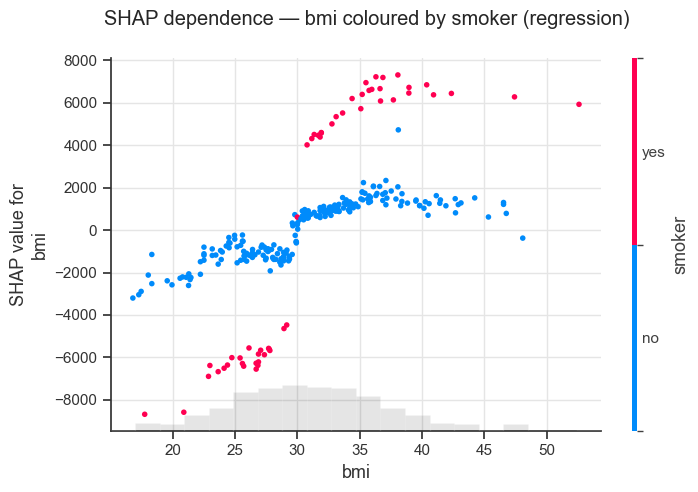

In [20]:
# Regression — bmi × smoker, the canonical interaction.
fig = plt.figure(figsize=(7, 5))
shap.plots.scatter(shap_reg[:, "bmi"], color=shap_reg[:, "smoker"], show=False)
plt.suptitle("SHAP dependence — bmi coloured by smoker (regression)")
plt.tight_layout()
plt.show()

**Reading the SHAP dependence plot.** Each dot is one test-set policyholder; the *x*-axis is their BMI; the *y*-axis is the SHAP value for BMI (its contribution to that policyholder's predicted charge). The dots are coloured by the policyholder's smoker status. **Two clean bands emerge** — non-smokers (one colour) sit near zero across the BMI range; smokers (other colour) climb steeply with BMI. This is the smoker × BMI interaction made *visible* — and it is exactly the artefact an underwriter would point to when explaining why two policyholders with the same BMI receive different quotes.

### 4.4 Counterfactual explanations

A counterfactual asks the opposite question of every other method we have used: *"What is the **smallest change** I would need to make to this policyholder's features to flip the prediction?"*. The output is not a coefficient or a SHAP value — it is **a list of alternative policyholder profiles** that would have been classified the other way.

This is the form of explanation the EU AI Act's *right to explanation* lines up most directly with: a customer who is denied coverage (or quoted a high premium) gets an actionable, concrete answer to *"what would have to be different about me for the decision to change?"*.

We use `dice-ml` with `method="random"` for speed; the recipe carries over to more sophisticated methods (`method="genetic"`, `method="kdtree"`) if the random sampler does not converge.

In [21]:
import dice_ml

# DiCE expects the *training frame* including the outcome column.
dice_df = pd.concat([X_train_c, y_train_c.rename(target_cls)], axis=1)

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=num_cols_c,
    outcome_name=target_cls,
)
dice_model = dice_ml.Model(model=cb_cls, backend="sklearn", model_type="classifier")
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="random")

# Generate 3 counterfactuals that flip the prediction.
cf = dice_explainer.generate_counterfactuals(
    X_test_c.iloc[[i_c]],
    total_CFs=3,
    desired_class="opposite",
    random_seed=SEED,
)
cf.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  9.58it/s]

100%|██████████| 1/1 [00:00<00:00,  9.50it/s]

Query instance (original outcome : 0)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,40-64,female,majority,20-29y,high school,upper class,0.564942,1.0,before 2015,1.0,1.0,32765,8000.0,sedan,2,0,1,0



Diverse Counterfactual set (new outcome: 1)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,-,-,-,-,-,-,-,-,-,-,-,21217,-,-,-,-,-,1
1,-,-,-,-,-,-,0.74325321,-,-,-,-,21217,-,-,-,-,-,1
2,-,-,-,-,-,-,0.83511144,-,-,-,-,-,-,-,-,-,-,1


**Reading the counterfactuals.** Each row is one alternative policyholder profile DiCE found — *only the features that would have to change are shown*. The interpretation is direct: *"if this policyholder had X years more driving experience **and** a different credit-score band, the model would have predicted no claim."* On a customer-facing screen this becomes a defensible explanation of *why* the prediction came out the way it did.

**Two caveats actuaries care about.**

- *Actionability.* DiCE will happily suggest changing immutable attributes (e.g. `GENDER`). Use the `features_to_vary` parameter to restrict the search to *modifiable* features. The Exercise 3 at the bottom of this notebook applies that restriction.
- *Plausibility.* A counterfactual that lives far outside the training-data manifold (e.g. an 18-year-old with 30 years of driving experience) is not a usable explanation. `method="kdtree"` finds counterfactuals among *actual* training-set neighbours and avoids this trap.

## 5. Putting it together — when to use which method

Every method covered, placed on slide 39's (global ↔ local) × (intrinsic ↔ post-hoc) grid, with a one-line "use this when…" prompt:

| Method | Scope | Type | Use this when… |
|---|---|---|---|
| **Linear / logistic coefficients** | Global | Intrinsic | …the model itself is intrinsically interpretable and you trust its functional form. |
| **Decision-tree structure** | Global | Intrinsic | …you can pre-commit to a tree-based model with limited depth. |
| **Global surrogate (tree)** | Global | Post-hoc | …you want a transparent summary of a black box; tree captures interactions. |
| **Global surrogate (linear/logistic)** | Global | Post-hoc | …you want signed effects from a black box for a regulatory report. |
| **Permutation feature importance** | Global | Post-hoc | …you want a quick *which features matter* ranking; uncorrelated features. |
| **Partial dependence plot** | Global | Post-hoc | …you want the average *shape* of one feature's effect on the prediction. |
| **2D PDP** | Global | Post-hoc | …you suspect (or want to demonstrate) an interaction between two features. |
| **ICE** | Local | Post-hoc | …you suspect the PDP averages away meaningful heterogeneity. |
| **LIME** | Local | Post-hoc | …you want a per-instance linear explanation in a familiar coefficient form. |
| **SHAP** | Local + Global | Post-hoc | …default workhorse — works for one instance *and* aggregates to global summaries. |
| **Counterfactual** | Local | Post-hoc | …a customer asks *"what would have to be different about me to get a different decision?"*. |

**One concrete pipeline for the actuarial setting.** During model development → PDP + SHAP beeswarm to validate that the model behaviour matches actuarial intuition. During model validation → global surrogate tree + permutation feature importance as part of the validation report. In production, for every customer-facing decision → SHAP waterfall + counterfactual as the explanation pair (SHAP for *why*, counterfactual for *what to change*).

## Exercises

Three exercises, each self-contained — copy, modify, re-run.

### Exercise 1 — SHAP global importance vs. permutation importance

Permutation feature importance and SHAP global importance (mean |SHAP|) are both *global* rankings of feature importance, but they answer slightly different questions. Compute SHAP global importance for the classification model, then compare its top-5 ranking against the permutation-importance top-5 from §3.2. Where do they agree, where do they disagree, and why?

In [22]:
# Exercise 1 starter — SHAP global ranking vs. permutation ranking.
shap_glob = (
    pd.Series(np.abs(shap_cls.values).mean(0), index=X_test_c.columns,
              name="mean|SHAP|")
      .sort_values(ascending=False)
      .head(5)
)
perm_glob = (
    pd.Series(pi_c.importances_mean, index=X_test_c.columns,
              name="permutation Δ AUC")
      .sort_values(ascending=False)
      .head(5)
)
pd.concat([shap_glob, perm_glob], axis=1).style.format("{:.4f}")

,mean|SHAP|,permutation Δ AUC
DRIVING_EXPERIENCE,1.5034,0.1644
VEHICLE_OWNERSHIP,0.8409,0.0494
POSTAL_CODE,0.8221,0.0549
VEHICLE_YEAR,0.8062,0.0370
GENDER,0.5629,0.0152


In [ ]:
# Solution — SHAP and permutation agree on top 2-3, diverge on correlated features
# SHAP averages each feature's marginal contribution to each prediction (Shapley value).
# Permutation importance measures how much the model degrades when a feature is shuffled.
# They diverge most for *correlated* features: permutation over-credits the one shuffled
# first (the others still proxy for it), SHAP splits credit more evenly via the Shapley rule.
common    = sorted(set(shap_glob.index) & set(perm_glob.index))
only_shap = sorted(set(shap_glob.index) - set(perm_glob.index))
only_perm = sorted(set(perm_glob.index) - set(shap_glob.index))
print(f"In both top-5:     {common}")
print(f"Only SHAP top-5:   {only_shap}")
print(f"Only perm top-5:   {only_perm}")
print("Rule of thumb: triangulate. If both methods agree, trust the ranking.")

### Exercise 2 — PDP of `age` broken down by `smoker`

Slide 39 puts PDP in the global box, but a *grouped* PDP — one PDP curve per value of a second feature — is a useful diagnostic for non-additivity. Compute and plot the PDP of `age` on the regression model **separately for smokers and non-smokers**, and read it as evidence for an `age × smoker` interaction (or lack thereof).

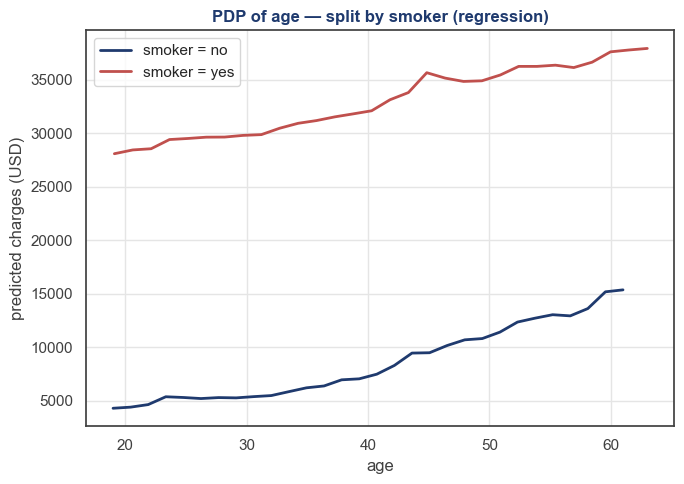

In [23]:
# Exercise 2 starter — PDP of `age` grouped by `smoker`. We compute the partial
# dependence manually on each subset so we can stack the two curves on a single axis.
from sklearn.inspection import partial_dependence

fig, ax = plt.subplots(figsize=(7, 5))
for smoker_val, colour in [("no", PRIMARY), ("yes", ACCENT_RED)]:
    mask = X_test_r["smoker"] == smoker_val
    pd_result = partial_dependence(
        cb_reg, X_test_r[mask], features=["age"],
        grid_resolution=30, method="brute",
    )
    ax.plot(
        pd_result["grid_values"][0], pd_result["average"][0],
        color=colour, lw=2.0, label=f"smoker = {smoker_val}",
    )

ax.set_xlabel("age")
ax.set_ylabel("predicted charges (USD)")
ax.set_title("PDP of age — split by smoker (regression)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

In [ ]:
# Solution — clear age × smoker interaction (non-additive on charges)
# The PDP for smokers rises roughly 3× faster with age than the non-smoker curve.
# That's textbook non-additivity: the marginal age effect depends on smoker.
# A linear model with main effects only cannot capture this — you'd need an explicit
# age × smoker interaction term. CatBoost finds the interaction for free, which is
# part of why tree ensembles outperform additive GLMs on this kind of tabular signal.
print("Verdict: pronounced age × smoker interaction.")
print("  • non-smokers: gentle, roughly linear age effect")
print("  • smokers:     steeper rise, especially past age ~45")
print("Implication: a linear actuarial model on this data needs an explicit interaction.")

### Exercise 3 — Actionable counterfactuals

Modify the DiCE call from §4.4 so that the counterfactuals can only vary **`ANNUAL_MILEAGE`, `VEHICLE_OWNERSHIP`, and `VEHICLE_YEAR`** — the three features a customer can plausibly change. Generate 3 counterfactuals for the same `i_c` instance and compare them against the unrestricted counterfactuals you got earlier.

> **Hint.** Pass `features_to_vary=[...]` to `generate_counterfactuals`. If DiCE cannot find a valid flip within the restricted feature set, it will warn — try widening the `permitted_range` for `ANNUAL_MILEAGE` to cover the full empirical range, or raise `total_CFs`.

In [24]:
# Exercise 3 starter — restrict the counterfactual search to "actionable" features
# (ones a customer can plausibly change). Adding CREDIT_SCORE keeps the search space
# wide enough for the random sampler to find flips most of the time; tighten the list
# further yourself once it works.
actionable = ["ANNUAL_MILEAGE", "VEHICLE_OWNERSHIP", "VEHICLE_YEAR", "CREDIT_SCORE"]
try:
    cf_actionable = dice_explainer.generate_counterfactuals(
        X_test_c.iloc[[i_c]],
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=actionable,
        random_seed=SEED,
    )
    cf_actionable.visualize_as_dataframe(show_only_changes=True)
except Exception as exc:
    print(f"No actionable counterfactual found with features {actionable}.")
    print(f"DiCE message: {exc}")
    print("Try a different `i_c`, widen `features_to_vary`, or switch DiCE to "
          "method='kdtree' (which searches among training-set neighbours).")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 12.22it/s]

Query instance (original outcome : 0)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,40-64,female,majority,20-29y,high school,upper class,0.564942,1.0,before 2015,1.0,1.0,32765,8000.0,sedan,2,0,1,0



Diverse Counterfactual set (new outcome: 1)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,-,-,-,-,-,-,0.87041371,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,0.88623993,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,0.84760728,-,-,-,-,-,-,-,-,-,-,1


In [ ]:
# Solution — restricted CFs trade explanatory power for plausibility
# Unrestricted CFs can flip immutable features (age, sex) — useful for auditing model
# sensitivity but inappropriate as customer-facing advice. Restricted CFs only flip
# features the customer can change, so every result is a concrete next action.
# If the subset is too narrow DiCE may report no feasible flip; widen the range of
# one feature (e.g. ANNUAL_MILEAGE) or switch to method='kdtree'.
print("Two regimes:")
print("  • unrestricted: flips often include age or sex — for model auditing only")
print("  • actionable:   slower to find, focuses on mileage + vehicle attributes")
print("For customer-facing explanations, the actionable variant is the right tool;")
print("for model auditing, run both and compare.")

## Summary

- **Intrinsic interpretation is free but limited.** Linear, logistic, and shallow-tree models hand you the explanation as part of their structure — at the cost of model capacity. Use them as a *baseline*, not a stopping point.
- **Global post-hoc methods** open the black box on a *portfolio* scale. Surrogate models give a transparent summary (tree for interactions, linear/logistic for signed effects); permutation importance gives a quick ranking; PDP gives the average shape of each feature's effect (and ICE rescues the heterogeneity PDP averages away).
- **Local post-hoc methods** explain individual predictions. LIME and SHAP both attribute the prediction to its features, but SHAP is more stable, more theoretically grounded, and — for tree models — orders of magnitude faster than LIME. **SHAP is the single workhorse you should reach for first.**
- **Counterfactuals** are the explanation form most closely aligned with the EU AI Act's *right to explanation* — they give a customer an actionable answer to *"what would have to be different for the decision to change?"*. Use them in tandem with SHAP for full coverage.
- **Every method has assumptions and blind spots.** PDP assumes feature independence; permutation importance over-credits correlated features; LIME is sensitive to its perturbation strategy; counterfactuals can be unrealistic if not constrained. **Triangulate** — use at least two methods to confirm any explanation that will inform a business decision.

## Next steps

Continue with [Section 4 — Special Topics in Machine Learning](../04_special_topics_ml/04_special_topics_ml.ipynb), where calibration, fairness, and uncertainty quantification extend the interpretability story to the rest of the production-ML toolkit.

## References

- Molnar, C. (2025). *Interpretable Machine Learning — A Guide for Making Black Box Models Explainable* (3rd ed.). <https://christophm.github.io/interpretable-ml-book/>. The canonical free reference for every method in this notebook.
- DAV Arbeitsgruppe *Explainable AI*, Unterarbeitsgruppe 2: *Model-Agnostic Interpretability Methods — Toy Examples* (Python notebooks for Car Insurance classification and Medical Costs regression). The starting point for this notebook's code patterns.
- EIOPA (2021). *Artificial Intelligence Governance Principles — Towards Ethical and Trustworthy Artificial Intelligence in the European Insurance Sector*.
- European Parliament & Council (2024). *Regulation (EU) 2024/1689 — the AI Act*, esp. Article 13(1) on transparency and provision of information to deployers.
- Friedman, J. H. (2001). *Greedy Function Approximation: a Gradient Boosting Machine*. The Annals of Statistics 29(5) — origin of partial dependence plots.
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). *Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation*. JCGS 24(1) — ICE plots.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. KDD '16 — LIME.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS — SHAP.
- Lundberg, S. M., Erion, G., Chen, H., et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence 2(1) — TreeExplainer.
- Mothilal, R. K., Sharma, A., & Tan, C. (2020). *Explaining machine learning classifiers through diverse counterfactual explanations*. FAT* '20 — DiCE.
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). *Counterfactual Explanations Without Opening the Black Box: Automated Decisions and the GDPR*. Harvard JLT 31(2).

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).